Saving att.bB7mW28LGV_Ip6ll2fiM_7wlMM83dNcx3YDWruDR3SI.jpeg to att.bB7mW28LGV_Ip6ll2fiM_7wlMM83dNcx3YDWruDR3SI.jpeg


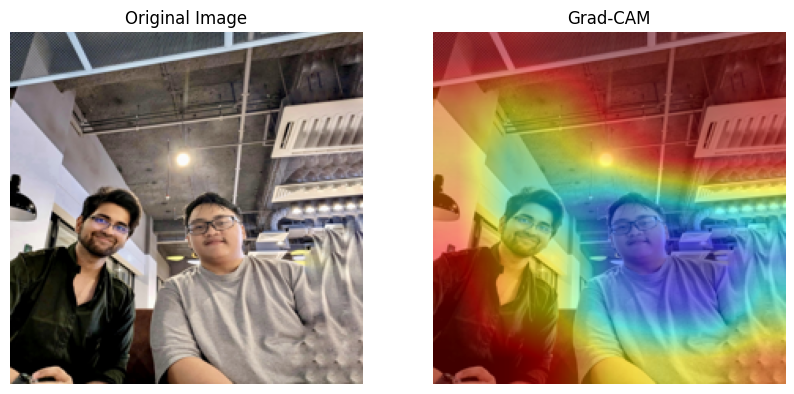

In [14]:
# Install required packages
!pip install -q torchvision matplotlib opencv-python

# Import libraries
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.utils import make_grid
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab import files
from io import BytesIO

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Load image and preprocess
image = Image.open(image_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
input_tensor = transform(image).unsqueeze(0)  # Add batch dimension

# Load a pretrained model (ResNet50)
model = models.resnet50(pretrained=True)
model.eval()

# You can replace the classifier for your own dataset if needed
# Example: model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# Register hook for Grad-CAM
gradients = []

def save_gradient(grad):
    gradients.append(grad)

# Pick the target layer (last conv layer of ResNet50)
target_layer = model.layer4[2].conv3

# Forward hook to capture activations
activations = []

def forward_hook(module, input, output):
    activations.append(output)
    output.register_hook(save_gradient)

# Register hooks
hook = target_layer.register_forward_hook(forward_hook)

# Forward pass
output = model(input_tensor)
pred_class = output.argmax().item()

# Backward pass
model.zero_grad()
class_score = output[0, pred_class]
class_score.backward()

# Get Grad-CAM
grads = gradients[0].squeeze().detach().numpy()
acts = activations[0].squeeze().detach().numpy()

# Compute weights and Grad-CAM map
weights = np.mean(grads, axis=(1, 2))
cam = np.zeros(acts.shape[1:], dtype=np.float32)

for i, w in enumerate(weights):
    cam += w * acts[i]

# Normalize the CAM
cam = np.maximum(cam, 0)
cam = cv2.resize(cam, (224, 224))
cam = cam - cam.min()
cam = cam / cam.max()

# Overlay CAM on image
img_np = np.array(image.resize((224, 224))) / 255.0
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = np.float32(heatmap) / 255
overlayed_img = heatmap + np.float32(img_np)
overlayed_img = overlayed_img / overlayed_img.max()

# Plotting
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img_np)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Grad-CAM')
plt.imshow(overlayed_img)
plt.axis('off')
plt.show()